**Paper**: Dobrescu and Shanker (2022), [*A fast upper envelope scan method for discrete-continuous dynamic programming*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4181302)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve
We use the separable utility specification $\mathrm{u}(c, H_{\succ}) = \alpha\,c^{1-\gamma_c}/(1{-}\gamma_c) + (1{-}\alpha)\,(\kappa H_{\succ})^{1-\gamma_h}/(1{-}\gamma_h)$.

In [2]:
# Parameters and settings
param_settings_for_nb = {
    'settings': {
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 600, 'n_a': 600, 'n_h': 600,
    },
    'calibration': {
        't0': 20, 'T': 100, 'tau': 0.07,
        'sigma_w': 0.11, 'phi_w': 0.86,
        'beta': 0.89, 'R': 1.04, 'rho': 2.5,
    },
}

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout

# Solve under each method
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        _mo = {
            ('adjuster_cons',
             'cntn_to_dcsn_mover',
             'upper_envelope'): method,
        }
        nest, grids = solve(
            SYNTAX, ue_method=_mo,
            verbose=False, progress='bar',
            draw=param_settings_for_nb)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


Solving:   0%|          | 0/51 [00:00<?, ?it/s]

Solving:   0%|          | 0/51 [00:14<?, ?it/s, age=70, warmup=1]

Solving:   2%|▏         | 1/51 [00:14<11:43, 14.07s/it, age=70, warmup=1]

Solving:   2%|▏         | 1/51 [00:14<11:43, 14.07s/it, age=69, warmup=1]

...

Solving:  98%|█████████▊| 50/51 [01:00<00:01,  1.05s/it, age=21, avg_adj_ms=69, avg_keeper_ms=235]

Solving:  98%|█████████▊| 50/51 [01:01<00:01,  1.05s/it, age=20, avg_adj_ms=69, avg_keeper_ms=236]

Solving: 100%|██████████| 51/51 [01:01<00:00,  1.05s/it, age=20, avg_adj_ms=69, avg_keeper_ms=236]

Solving: 100%|██████████| 51/51 [01:01<00:00,  1.21s/it, age=20, avg_adj_ms=69, avg_keeper_ms=236]


  51 periods, ages 20–70
  r=0.045, R=1.04, r_H=0, R_H=1.0, beta=0.89, alpha=0.7, gamma_c=3.5, gamma_h=1.5, kappa=0.06, sigma=0.001, delta=0, tau=0.07, chi=0, theta=1.3498, K=1.3, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30, rho=2.5
  n_a=600, n_h=600, n_w=600, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)            303          33         866        75
  NEGM(FUES)           236          69         721        62


## 3. Adjuster policies
We now plot adjuster financial assets $a_{\succ}$ and housing choice $H_{\succ}$ as functions of market resources $w_{\text{adj}}$ for the adjuster. First start with the model solved with EGM and FUES for both the adjuster and the keeper.

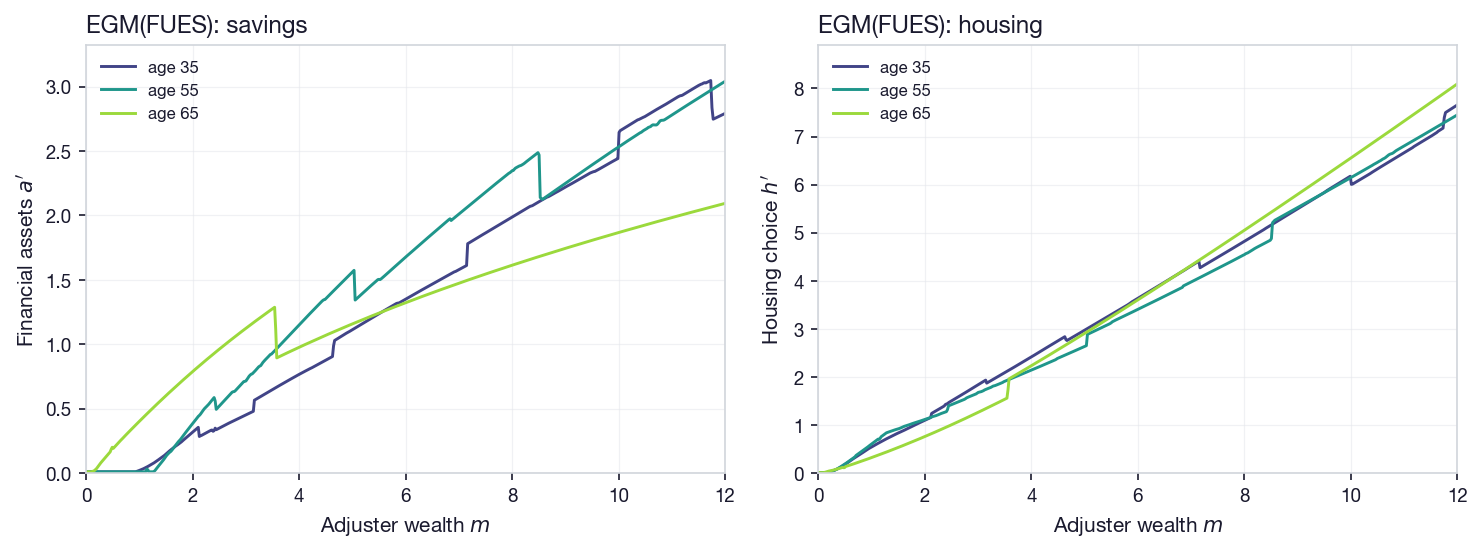

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[35, 55, 65], methods_filter=['FUES'], xlim =12)

NEGM(FUES):

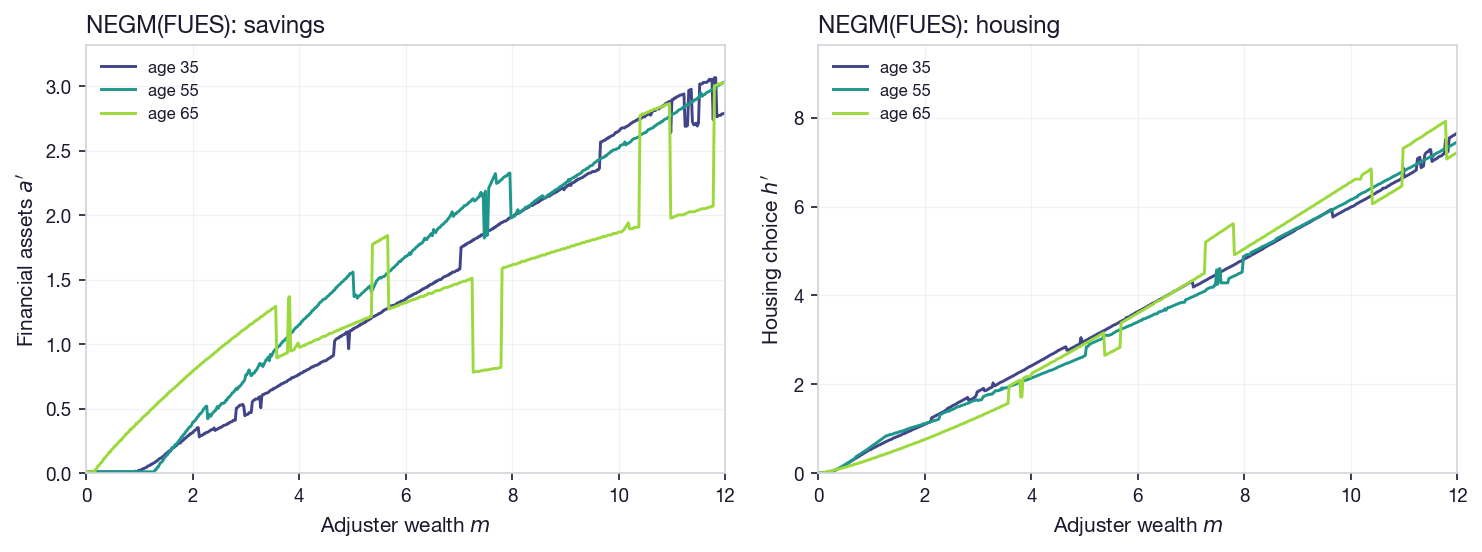

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[35, 55, 65], methods_filter=['NEGM'], xlim =12)

## 4. Adjuster EGM grid
The EGM over the $H_{\succ}$ grid produces an endogenous wealth grid where **multiple housing choices map to the same wealth level**. The left panel shows raw EGM candidates for financial assets $a_{\succ}$; the middle panel shows housing $H_{\succ}$; the right panel shows the value correspondence $\mathrm{v}(\hat{m})$. Each scatter point is one $(H_{\succ}, a_{\succ})$ root of the coupled FOCs. FUES scans this dense cloud to recover the upper envelope in a single pass. MSS and LTM require locally isolated points on the exogenous grid to separate unique segments before interpolating over each of them; because of multiple endogenous grid for each exogenous grid point, neither method can identify these segments.

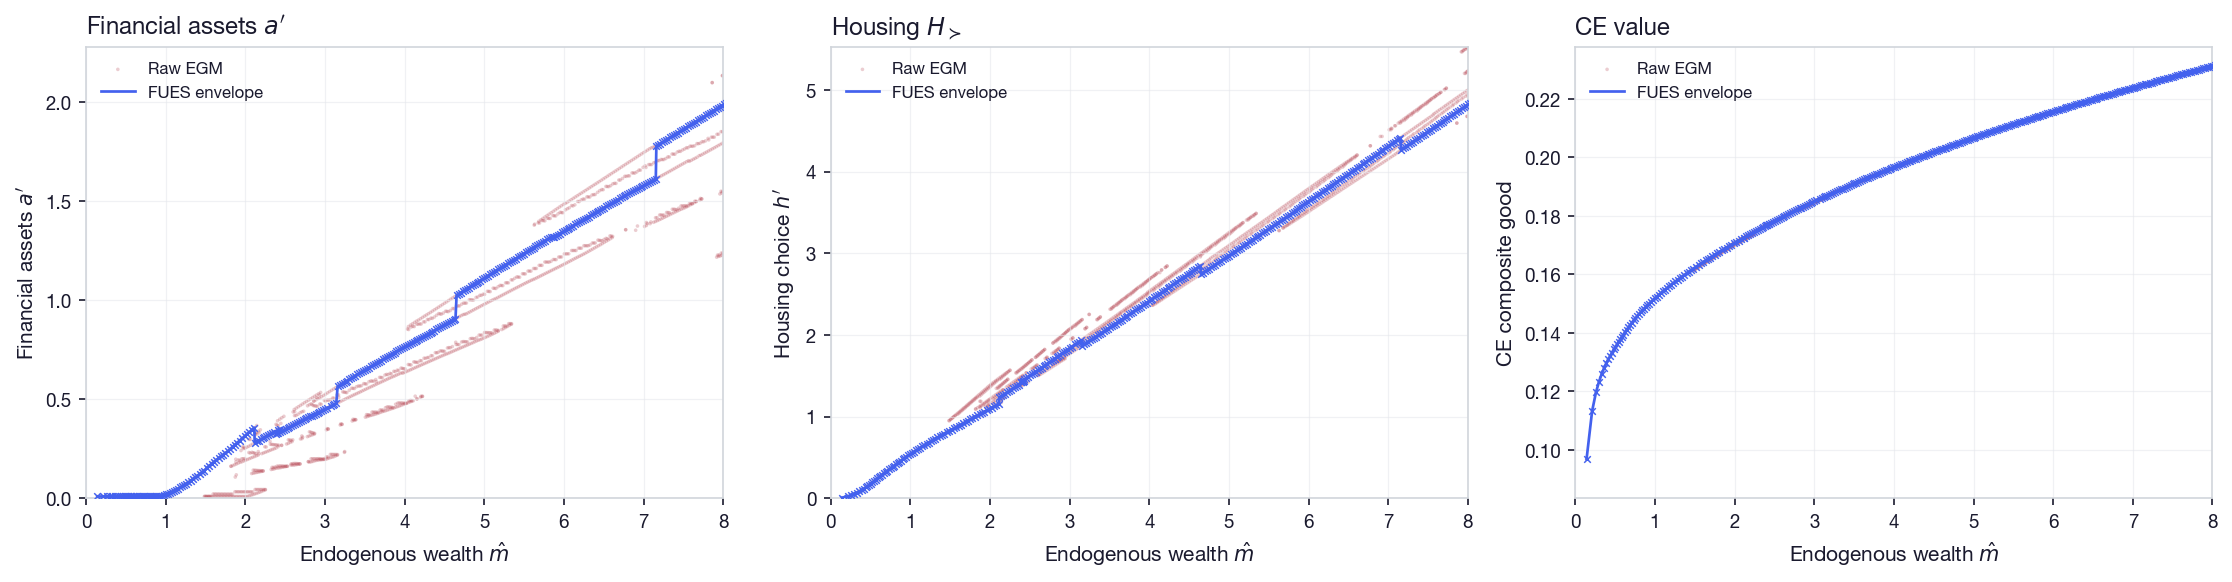

In [5]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=35, xlim =8)

Interactive (Plotly):

In [6]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=35)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies
Keeper consumption $c$ and savings $a_{\succ}$ as functions of cash-on-hand $w_{\mathrm{kp}}$, for a fixed housing level $H$. The keeper has a single control (consumption); housing passes through unchanged. (Recall that for the keeper, MSS *and* LTM can be applied to recover the upper envelope since each exogenous grid point maps to a unique endogenous grid point *and* the continuation-state policy only jumps  upwards)

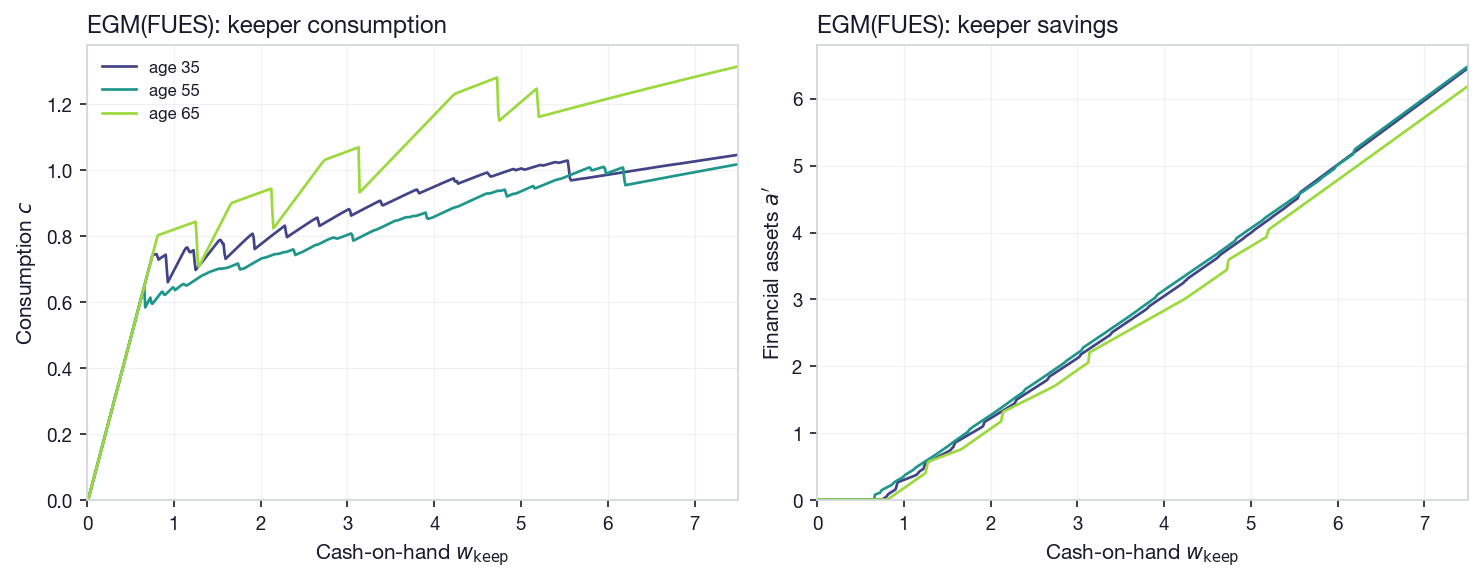

In [7]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[35, 55, 65], methods_filter=['FUES'])

NEGM(FUES):

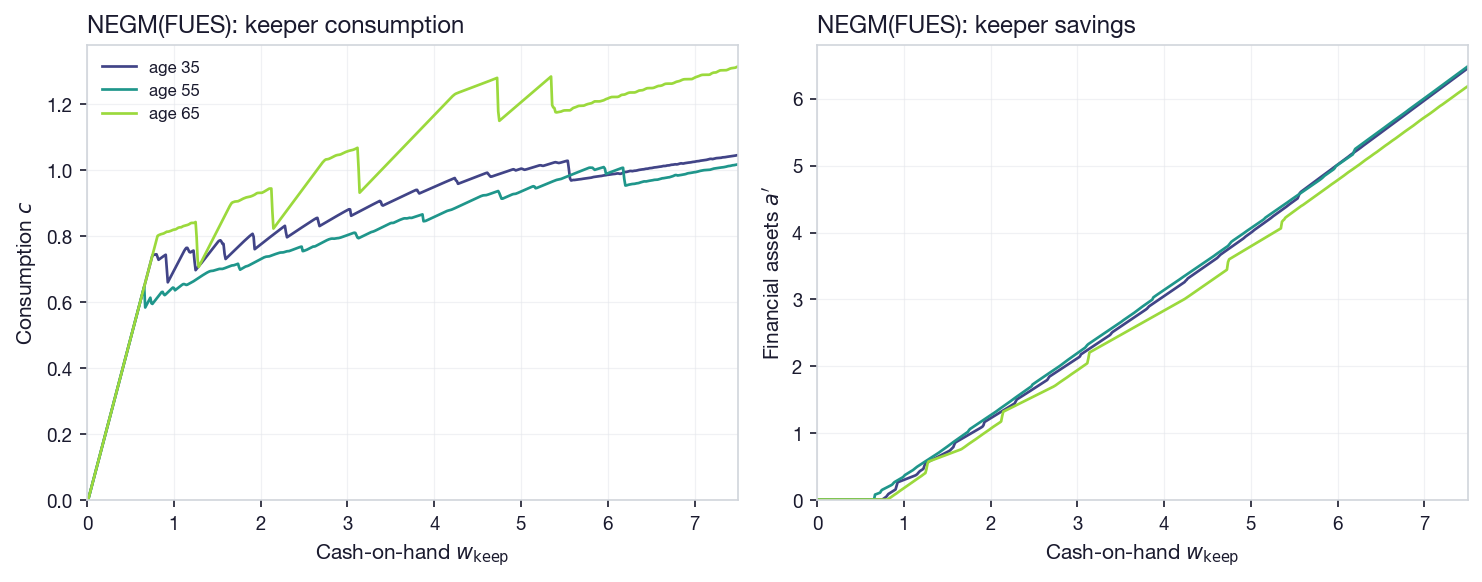

In [8]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[35, 55, 65], methods_filter=['NEGM'])

## 6. Euler equation errors
We forward-simulate 10,000 agents and evaluate two Euler residuals — one for the liquid asset and one for the durable — measured as $\log_{10}$ relative error ($-4$ = four digits of accuracy). We assume agents start with an average of $\$ 50,000$ in cash-on-hand.

In [9]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(
        r['nest'], r['grids'],
        N=10_000, seed=41, init_dispersion=0.5)
    euler_c = evaluate_euler_c(
        sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(
        sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c,
        'euler_h': euler_h,
        'euler': euler_c,
        'stats_c': compute_euler_stats(
            euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(
            euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(
            euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


Euler histograms:

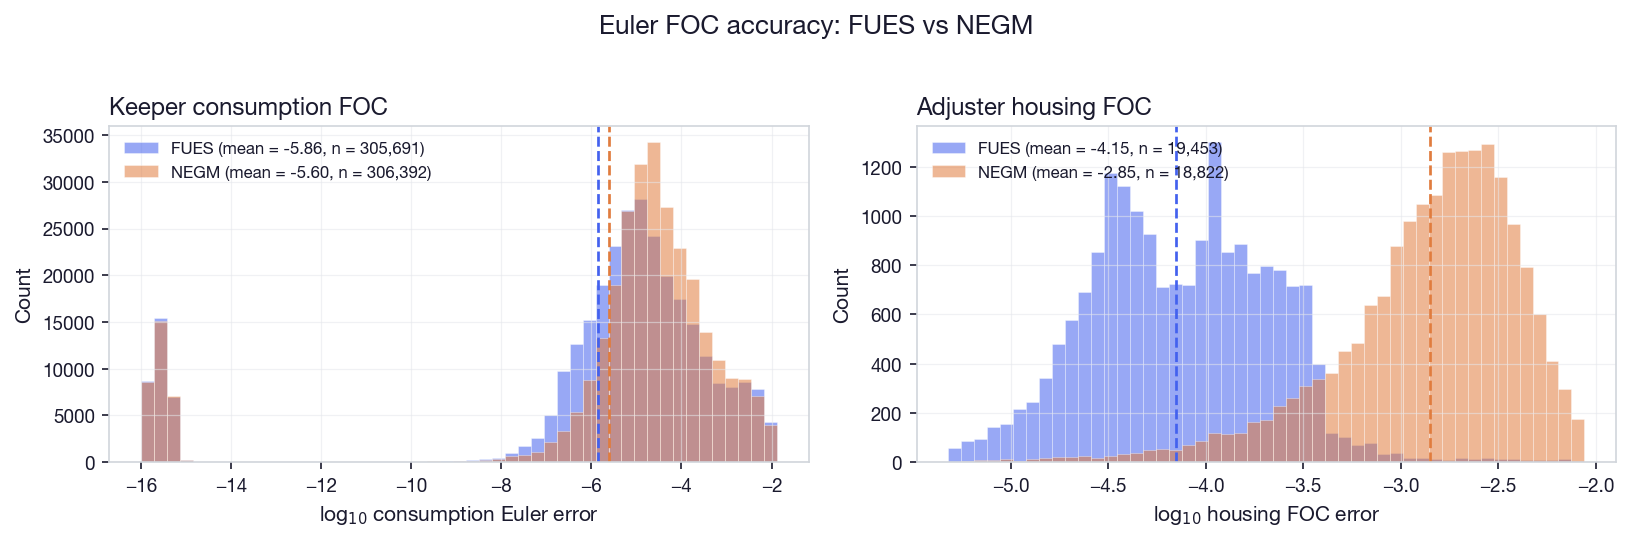

In [10]:
fig = plot_euler_histogram(euler_results)

### Welfare distribution
Per-agent certainty-equivalent utility at the start of the lifecycle, computed from the discounted NPV of flow utilities over the lifecycle.

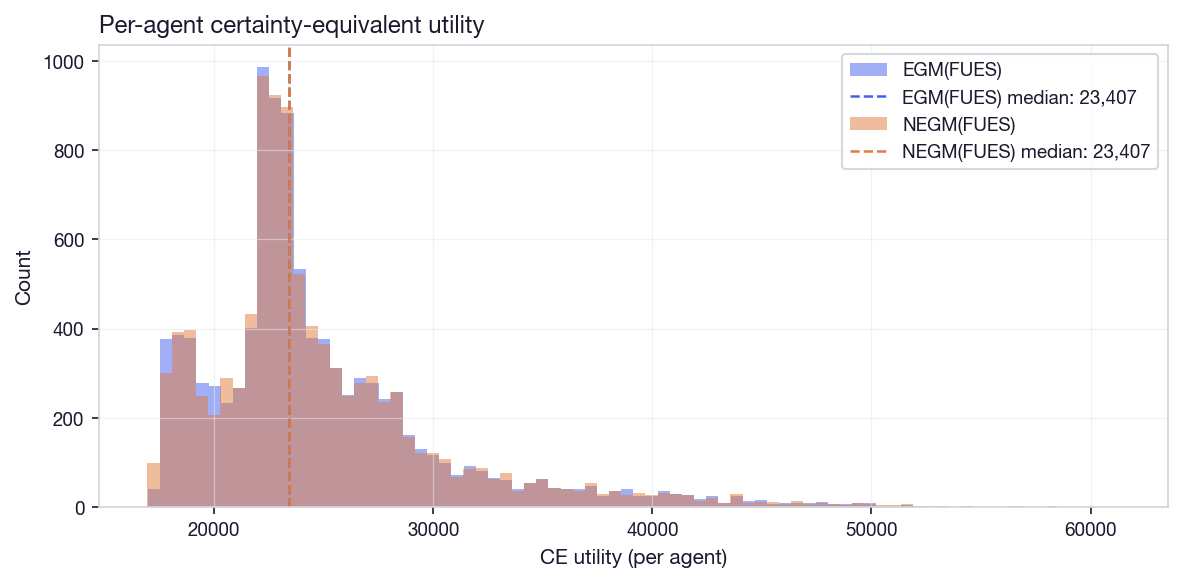

In [11]:
# Per-agent CE utility histogram
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0][
    'stages']['keeper_cons']
_rho = float(_st.calibration.get(
    'gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data'][
        'npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(
        inner > 0,
        inner ** (1.0 / (1.0 - _rho)),
        np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(
        ce, bins=80, alpha=0.5,
        label=_labels[method],
        color=_colors[method])
    ax.axvline(
        np.median(ce), color=_colors[method],
        ls='--', lw=1.2,
        label=f'{_labels[method]} median:'
              f' {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title(
    'Per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Comparison of errors and aggregates
The advantage of EGM FUES in the adjuster problem here is one to two orders of magnitude in accuracy over NEGM(FUES). Because FUES is already used for the keeper problem, the overall improvement in speed is modest (and will depend on the choice of numerical optimization used in the adjuster stage).

In [12]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 303 | 236 |
| Adjuster (ms/period) | 33 | 69 |
| Total (ms/period) | 1203 | 1026 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -5.86 | -5.60 |
| Consumption: adjuster | -10.28 | -9.57 |
| Consumption: all | -6.13 | -5.83 |
| Housing: adjuster | -4.15 | -2.85 |
| **Simulation** |  |  |
| CE utility | 23,251.46 | 23,251.28 |
| Mean consumption ($) | 62,885 | 62,881 |
| Mean fin. assets ($) | 41,051 | 40,992 |
| Mean housing ($) | 207,829 | 207,892 |
| Adjustment rate (%) | 18.0 | 18.1 |

## 8. Lifecycle profiles
Mean consumption, financial assets, and housing over the lifecycle. 

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


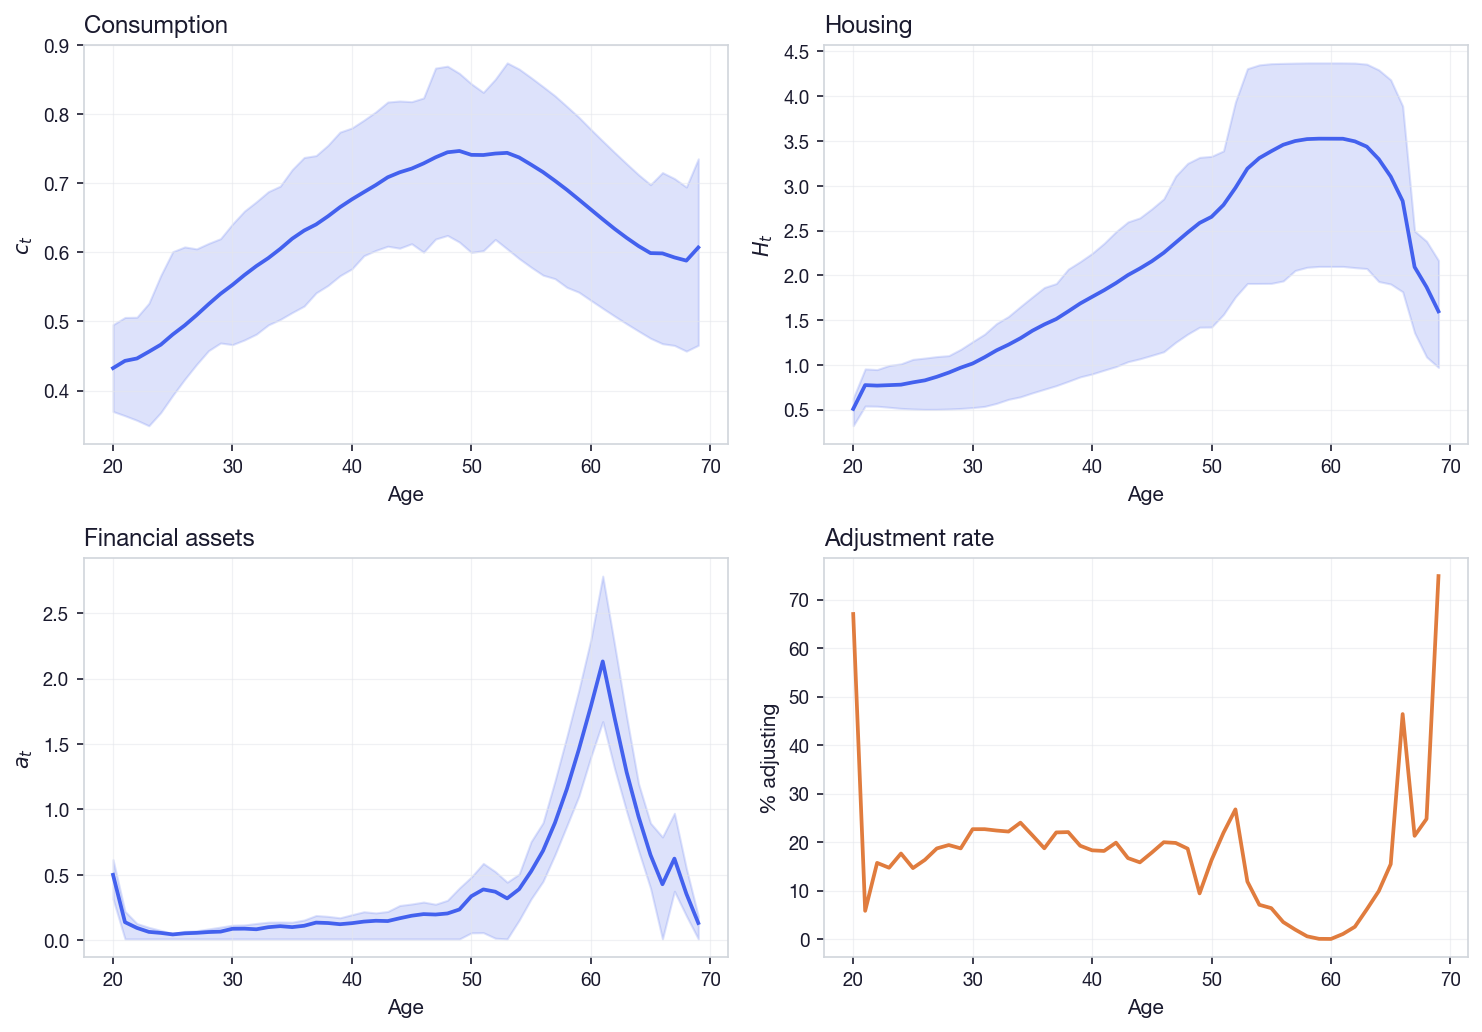

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


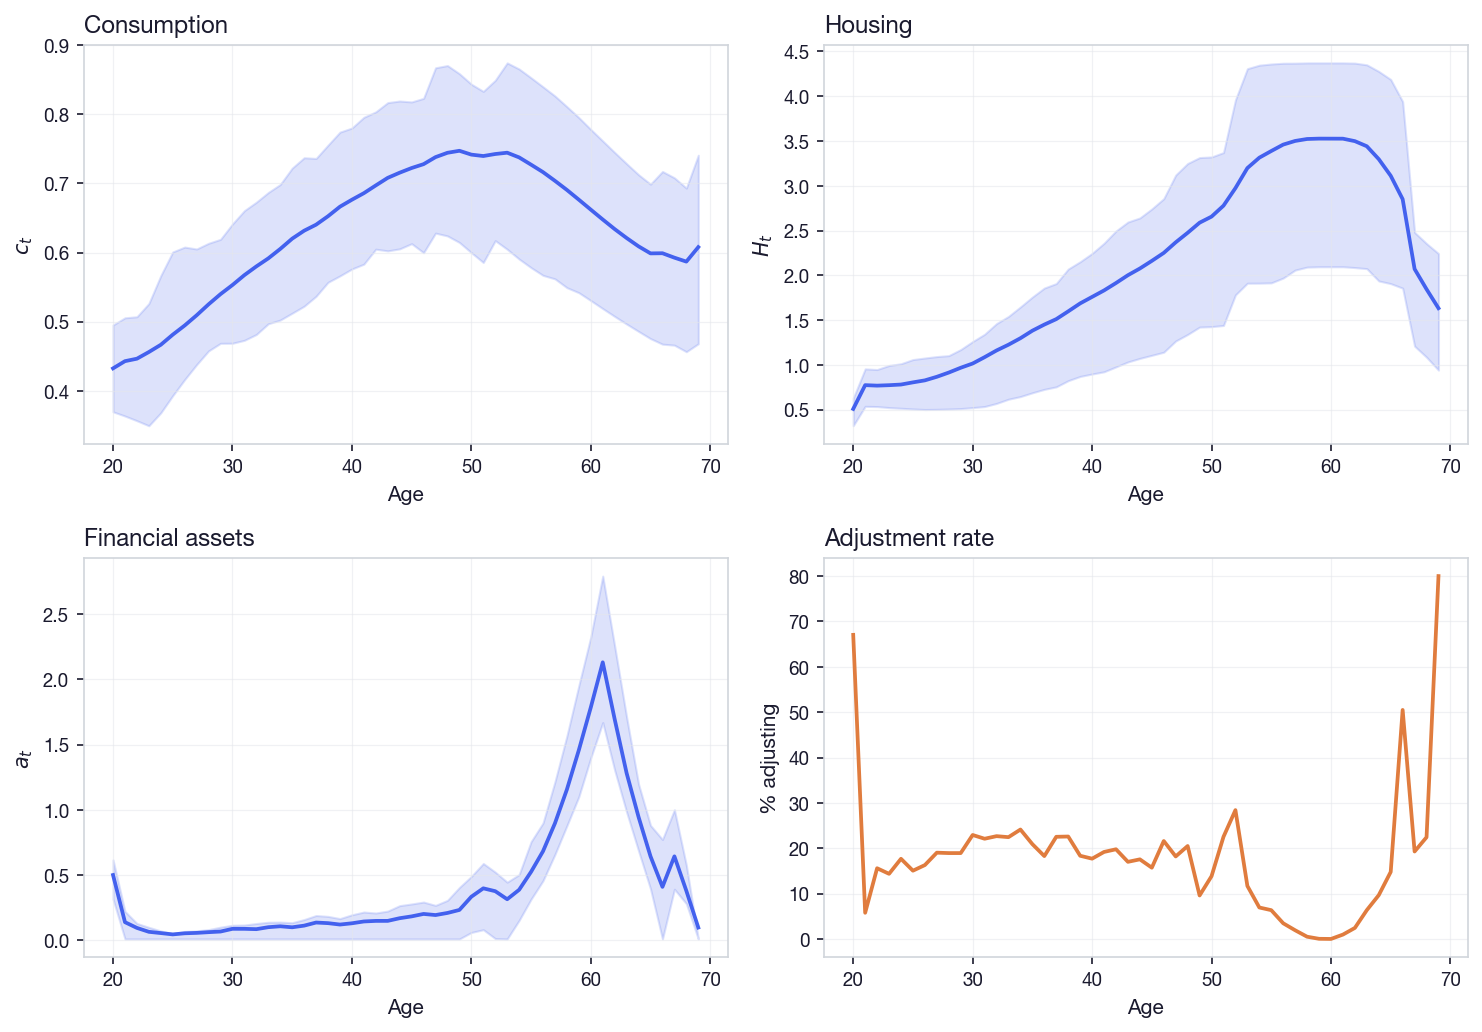

In [13]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

NEGM(FUES):

In [14]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 44,896.32 | 10,699.91 | 17,049.25 | 22,856.42 | 72,073.13 | 33,834.06 |
| 25–29 | 50,997.52 | 13,273.86 | 5,654.80 | 8,599.27 | 87,638.46 | 48,636.02 |
| 30–34 | 57,940.26 | 13,906.40 | 9,352.65 | 13,599.63 | 115,735.80 | 70,858.83 |
| 35–39 | 64,182.72 | 14,669.45 | 12,005.17 | 16,371.65 | 152,569.46 | 91,773.34 |
| 40–44 | 69,707.76 | 14,906.31 | 14,737.78 | 19,347.93 | 191,739.98 | 108,874.98 |
| 45–49 | 73,569.46 | 15,028.01 | 20,473.14 | 25,001.86 | 236,782.59 | 126,394.19 |
| 50–54 | 74,114.54 | 15,486.84 | 36,136.21 | 35,246.29 | 298,373.61 | 146,745.08 |
| 55–59 | 70,263.38 | 16,012.47 | 94,456.48 | 56,382.07 | 347,852.07 | 156,937.62 |
| 60–64 | 63,474.97 | 14,828.53 | 156,832.11 | 76,555.41 | 345,656.26 | 154,797.49 |
| 65–69 | 59,700.80 | 15,035.29 | 43,815.99 | 40,810.96 | 229,870.88 | 127,331.55 |

**NEGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 44,897.33 | 10,703.63 | 17,056.89 | 22,862.18 | 72,077.06 | 33,833.77 |
| 25–29 | 51,001.63 | 13,264.37 | 5,662.94 | 8,613.45 | 87,618.09 | 48,636.12 |
| 30–34 | 57,941.08 | 13,903.77 | 9,341.67 | 13,593.72 | 115,714.11 | 70,891.03 |
| 35–39 | 64,210.10 | 14,647.95 | 11,970.20 | 16,396.81 | 152,551.11 | 91,823.26 |
| 40–44 | 69,647.44 | 14,953.05 | 14,795.45 | 19,318.70 | 191,659.25 | 108,967.98 |
| 45–49 | 73,577.91 | 15,029.13 | 20,388.55 | 25,043.48 | 236,879.72 | 126,237.23 |
| 50–54 | 74,100.83 | 15,516.72 | 36,184.45 | 35,273.12 | 298,400.75 | 146,710.52 |
| 55–59 | 70,270.50 | 15,993.98 | 94,371.35 | 56,653.81 | 347,980.29 | 156,286.32 |
| 60–64 | 63,466.95 | 14,807.13 | 156,718.57 | 76,941.18 | 345,812.70 | 154,202.69 |
| 65–69 | 59,697.81 | 15,098.45 | 43,428.97 | 40,695.91 | 230,228.22 | 128,279.51 |